In [1]:
#Biblioteki
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras import datasets

import statsmodels.api as sm #Do pobierania szeregów czasowych

import keras

from keras import layers
from keras.models import Sequential
from keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.metrics import MeanAbsolutePercentageError
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint # Do zapisywania najlepszego modelu

from tensorflow.keras import layers, models
from keras.src import optimizers


from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error # kryteria dokładności prognozy RMSE, MAE, MAPE
from sklearn.preprocessing import MinMaxScaler # Do normalizacji danych przed uczeniem
import matplotlib.pyplot as plt

### Wczytanie danych

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rakannimer/air-passengers")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'air-passengers' dataset.
Path to dataset files: /kaggle/input/air-passengers


In [3]:
#df = pd.read_csv("/kaggle/input/air-passengers/AirPassengers.csv")
#df.index = pd.to_datetime(df['Month'], format='%Y-%m')

In [4]:
df = sm.datasets.get_rdataset('ausbeer', 'fpp2', cache=True).data

In [5]:
df.head()

,time,value
0,1956.00,284
1,1956.25,213
2,1956.50,227
3,1956.75,308
4,1957.00,262


In [6]:
plt.figure(figsize=(15,5))
plt.plot(df['#Passengers'])
plt.xticks(rotation = 90, size = 5)
plt.grid(True)
plt.show()

KeyError: '#Passengers'

<Figure size 1500x500 with 0 Axes>

<Axes: >

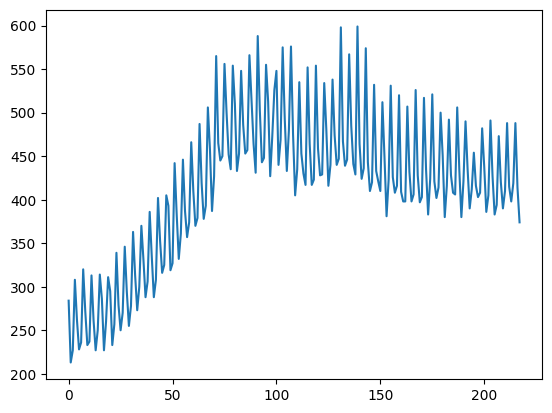

In [7]:

wartosci = df['value']
#wartosci = df["#Passengers"] #Zmieniamy przy wyborze szeregu
wartosci.plot()
# Będziemy pracować na tym

In [139]:

# Tworzymy sekwencje dla RNN
def rnn_sequence(dane, seq_len):
    dane = dane.to_numpy()
    X, y =  [], []
    for i in range(len(dane) - seq_len):
        seq = [[x] for x in dane[i : i + seq_len]]
        X.append(seq)
        label = dane[i + seq_len]
        y.append(label)
    return np.array(X), np.array(y)

# Długość sekwencji
# Chcemy brać 11 miesięcy w sekwencji i przewidywać 12 miesiąc

seq_len = 5
# Następnie przechodzimy o 1 krok w prawo i wykorzystujemy 12. prognozowany miesiąc do kolejnej prognozy

X, y = rnn_sequence(wartosci, seq_len=seq_len)

X[:1] # Macierz - ciąg liczby pasażerów w następnych 11 miesiącach

array([[[284],
        [213],
        [227],
        [308],
        [262]]])

In [140]:
X.shape

(213, 5, 1)

In [141]:
y.shape

(213,)

In [142]:
# Dopiero teraz rozdzielamy zbiór na treningowy, walidacyjny, testowy
#Pozostają nam 133 obserwacje
data_len = X.shape[0]
test_len = 12
val_len = 6

X_train, y_train = X[:data_len-test_len-val_len], y[:data_len-test_len-val_len] # zbiór uczący
X_val, y_val = X[data_len-val_len-test_len:data_len-test_len], y[data_len-val_len-test_len:data_len-test_len] # 6 obserwacji do zbioru walidacyjnego
X_test, y_test = X[data_len-test_len:], y[data_len-test_len:] # zbiór testowy

In [143]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape

((195, 5, 1), (195,), (6, 5, 1), (6,), (12, 5, 1))

## Tworzymy model
### Wykorzystanie LSTM

In [144]:
# Tworzymy model1
model1 = Sequential()
model1.add(InputLayer((seq_len,1)))
model1.add(LSTM(64))
model1.add(Dense(8, 'relu'))
model1.add(Dense(1,'linear')) # Wyjście

model1.summary()


Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                  │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,425 (68.07 KB)

 Trainable params: 17,425 (68.07 KB)

 Non-trainable params: 0 (0.00 B)

In [145]:
model1.compile(loss = MeanSquaredError(), optimizer=Adam(learning_rate = 0.002), metrics=[RootMeanSquaredError()])

In [146]:
model1.fit(X_train, y_train, validation_data=(X_val, y_val), epochs = 100)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 184596.3594 - root_mean_squared_error: 429.6417 - val_loss: 178570.4844 - val_root_mean_squared_error: 422.5760
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 183632.7812 - root_mean_squared_error: 428.5191 - val_loss: 178096.1406 - val_root_mean_squared_error: 422.0144
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 182393.0000 - root_mean_squared_error: 427.0499 - val_loss: 177642.3281 - val_root_mean_squared_error: 421.4764
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 175038.2969 - root_mean_squared_error: 418.2847 - val_loss: 176949.8750 - val_root_mean_squared_error: 420.6541
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 181658.6250 - root_mean_squared_error: 426.2040 - val_loss: 176438.0781 - val_root_mean_squared_error: 420.0453
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 180826.2188 - root_mean_squared_error: 425.2278 - val_loss: 175739.2500 - val_root_mean_squa

In [147]:
model1.compile(loss = MeanSquaredError(), optimizer=Adam(learning_rate = 0.0001), metrics=[RootMeanSquaredError()])

In [148]:
model1.fit(X_train, y_train, validation_data=(X_val, y_val), epochs = 400)

Epoch 1/400
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 14228.5625 - root_mean_squared_error: 119.2408 - val_loss: 8373.3564 - val_root_mean_squared_error: 91.5060
Epoch 2/400
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 12877.5518 - root_mean_squared_error: 113.2766 - val_loss: 8331.0166 - val_root_mean_squared_error: 91.2744
Epoch 3/400
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 13511.7666 - root_mean_squared_error: 116.2255 - val_loss: 8289.3232 - val_root_mean_squared_error: 91.0457
Epoch 4/400
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 13420.2969 - root_mean_squared_error: 115.8292 - val_loss: 8246.6982 - val_root_mean_squared_error: 90.8113
Epoch 5/400
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 13468.1182 - root_mean_squared_error: 116.0265 - val_loss: 8206.5928 - val_root_mean_squared_error: 90.5902
Epoch 6/400
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 13638.5352 - root_mean_squared_error: 116.7558 - val_loss: 8165.8730 - val_root_mean_squared_error: 90.3652
Epoc

In [149]:
predykcje_train = model1.predict(X_train).flatten()
wyniki_train = pd.DataFrame(data={'Predykcje': predykcje_train, 'Rzeczywiste':y_train})
wyniki_train

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


,Predykcje,Rzeczywiste
0,274.025360,228
1,263.656128,236
2,270.280914,320
3,294.839355,272
4,279.588348,233
...,...,...
190,420.164368,454
191,419.924774,416
192,418.115723,403
193,418.738525,408


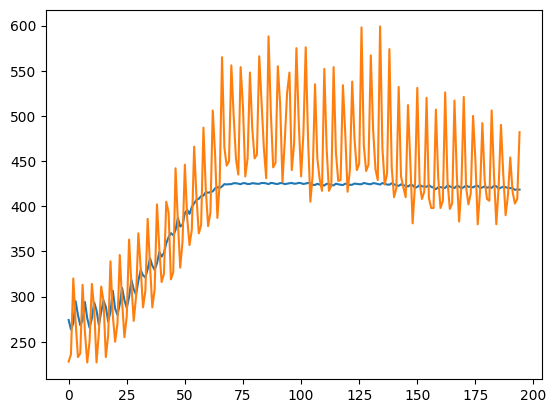

In [150]:
plt.plot(wyniki_train['Predykcje']) # Niebieskie
plt.plot(wyniki_train['Rzeczywiste'])

In [151]:
predykcje_test = model1.predict(X_test).flatten()
wyniki_test = pd.DataFrame(data={'Predykcje': predykcje_test, 'Rzeczywiste':y_test})
wyniki_test

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


,Predykcje,Rzeczywiste
0,418.804108,394
1,417.762634,473
2,418.917419,420
3,417.387024,390
4,417.612244,410
5,418.613281,488
6,420.791504,415
7,419.605530,398
8,419.651062,419
9,420.048279,488


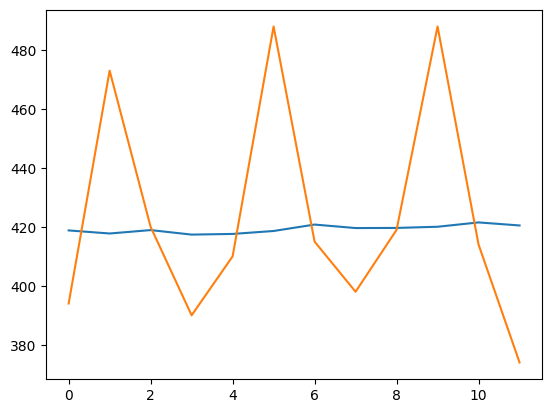

In [152]:
plt.plot(wyniki_test['Predykcje']) # Niebieskie
plt.plot(wyniki_test['Rzeczywiste'])

## Funkcja automatyzująca proces uczenia

In [153]:
def nowy_model(model, epoki1=100, lr1=0.001, epoki2=100, lr2=0.0001):

    model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=lr1), metrics=[RootMeanSquaredError()])
    model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs = epoki1)

    model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=lr2), metrics=[RootMeanSquaredError()])
    model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs = epoki2)

    predykcje_train = model.predict(X_train).flatten()
    wyniki_train = pd.DataFrame(data={'Predykcje': predykcje_train, 'Rzeczywiste': y_train}).reset_index(drop=True)

    plt.figure(figsize=(18, 6))
    plt.title('TRENINGOWY: Rzeczywiste vs Predykcje', fontsize=16)
    plt.plot(wyniki_train['Rzeczywiste'], label='Wartości Rzeczywiste', color='black', alpha=0.6)
    plt.plot(wyniki_train['Predykcje'], label='Predykcje Modelu', color='#ff7f0e', alpha=0.8)
    plt.legend(loc='best', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

    predykcje_test = model.predict(X_test).flatten()
    wyniki_test = pd.DataFrame(data={'Predykcje': predykcje_test, 'Rzeczywiste': y_test}).reset_index(drop=True)

    plt.figure(figsize=(18, 6))
    plt.title('TESTOWY: Rzeczywiste vs Predykcje', fontsize=16)
    plt.plot(wyniki_test['Rzeczywiste'], label='Wartości Rzeczywiste', color='black', alpha=0.6)
    plt.plot(wyniki_test['Predykcje'], label='Predykcje Modelu', color='#ff7f0e', alpha=0.8)
    plt.legend(loc='best', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

    return model

## Model 2

In [154]:
# Tworzymy model2
model2 = Sequential()
model2.add(InputLayer((seq_len,1)))
model2.add(LSTM(64, return_sequences=True)) # Zwracamy pełną informację dla kolejnej warstwy LSTM
model2.add(LSTM(64))
model2.add(Dense(16, 'relu'))
model2.add(Dense(8, 'relu'))
model2.add(Dense(1,'linear')) # Wyjście

model2.summary()

Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_17 (LSTM)                  │ (None, 5, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,105 (199.63 KB)

 Trainable params: 51,105 (199.63 KB)

 Non-trainable params: 0 (0.00 B)

In [155]:
model2.compile(loss = MeanSquaredError(), optimizer=Adam(learning_rate = 0.001), metrics=[RootMeanSquaredError()])
model2.fit(X_train, y_train, validation_data=(X_val, y_val), epochs = 100)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 183560.8594 - root_mean_squared_error: 428.4284 - val_loss: 178807.2031 - val_root_mean_squared_error: 422.8560
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 185109.9844 - root_mean_squared_error: 430.2253 - val_loss: 178312.6719 - val_root_mean_squared_error: 422.2708
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 186481.3438 - root_mean_squared_error: 431.7521 - val_loss: 177584.7500 - val_root_mean_squared_error: 421.4081
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 188161.1250 - root_mean_squared_error: 433.7047 - val_loss: 176596.4531 - val_root_mean_squared_error: 420.2338
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 179952.6562 - root_mean_squared_error: 424.1960 - val_loss: 175378.3750 - val_root_mean_squared_error: 418.7820
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 182008.2812 - root_mean_squared_error: 426.5928 - val_loss: 174016.7344 - val_root_mean_squa

In [156]:
model2.compile(loss = MeanSquaredError(), optimizer=Adam(learning_rate = 0.0001), metrics=[RootMeanSquaredError()])
model2.fit(X_train, y_train, validation_data=(X_val, y_val), epochs = 400)

Epoch 1/400
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 7136.5723 - root_mean_squared_error: 84.3840 - val_loss: 1360.0298 - val_root_mean_squared_error: 36.8786
Epoch 2/400
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 6806.6069 - root_mean_squared_error: 82.4301 - val_loss: 1358.9347 - val_root_mean_squared_error: 36.8637
Epoch 3/400
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 7167.1479 - root_mean_squared_error: 84.6150 - val_loss: 1358.0558 - val_root_mean_squared_error: 36.8518
Epoch 4/400
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 7945.1626 - root_mean_squared_error: 89.0899 - val_loss: 1357.9225 - val_root_mean_squared_error: 36.8500
Epoch 5/400
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 8229.8555 - root_mean_squared_error: 90.5251 - val_loss: 1357.9253 - val_root_mean_squared_error: 36.8500
Epoch 6/400
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 7079.5088 - root_mean_squared_error: 84.1213 - val_loss: 1358.0963 - val_root_mean_squared_error: 36.8524
Epoch 7/400
7/7 

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


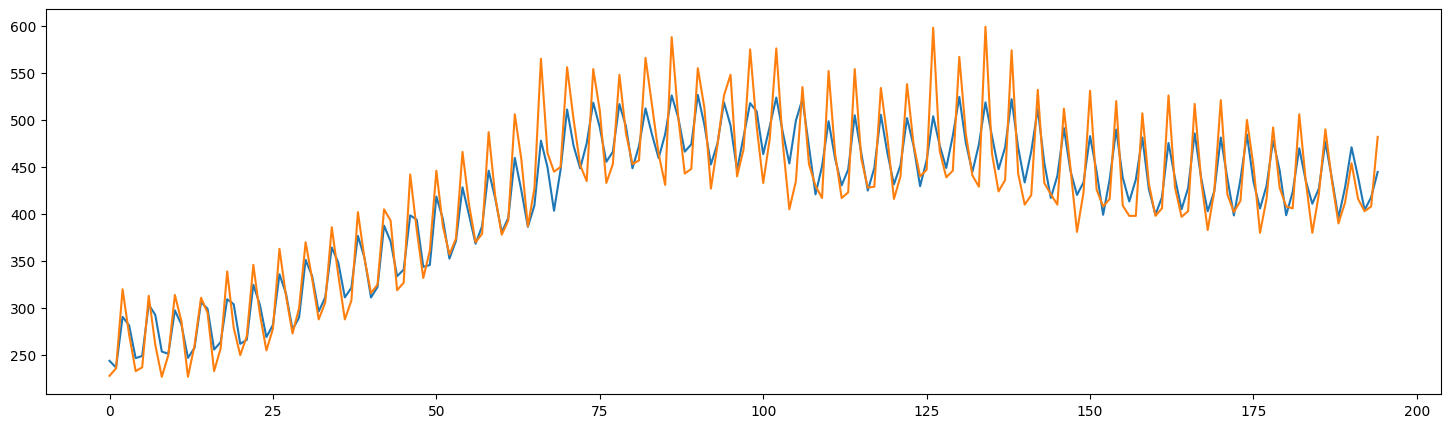

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


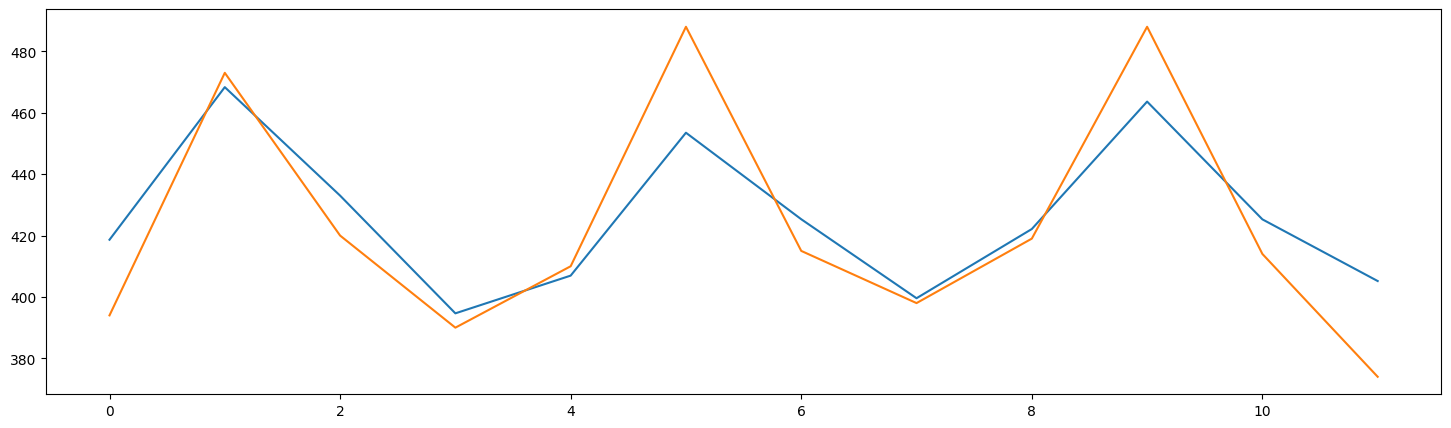

In [157]:
predykcje_train = model2.predict(X_train).flatten()
wyniki_train = pd.DataFrame(data={'Predykcje': predykcje_train, 'Rzeczywiste':y_train})
wyniki_train

plt.figure(figsize=(18,5))
plt.plot(wyniki_train['Predykcje']) # Niebieskie
plt.plot(wyniki_train['Rzeczywiste'])
plt.show()

predykcje_test = model2.predict(X_test).flatten()
wyniki_test = pd.DataFrame(data={'Predykcje': predykcje_test, 'Rzeczywiste':y_test})
wyniki_test
plt.figure(figsize=(18,5))
plt.plot(wyniki_test['Predykcje']) # Niebieskie
plt.plot(wyniki_test['Rzeczywiste'])

## Znaczna poprawa

## Model 3

In [161]:
model3 = Sequential()
model3.add(InputLayer((seq_len,1)))
model3.add(GRU(64, return_sequences=True)) # Zwracamy pełną informację dla kolejnej warstwy GRU
model3.add(GRU(64))
model3.add(Dense(16, 'relu'))
model3.add(Dense(8, 'relu'))
model3.add(Dense(1,'linear')) # Wyjście


Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 181418.2656 - root_mean_squared_error: 425.9218 - val_loss: 178941.3125 - val_root_mean_squared_error: 423.0146
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 185019.7812 - root_mean_squared_error: 430.1201 - val_loss: 178662.0000 - val_root_mean_squared_error: 422.6843
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 184142.3906 - root_mean_squared_error: 429.1047 - val_loss: 178332.0469 - val_root_mean_squared_error: 422.2938
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 178845.0938 - root_mean_squared_error: 422.8850 - val_loss: 177960.5469 - val_root_mean_squared_error: 421.8537
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 188836.3281 - root_mean_squared_error: 434.4319 - val_loss: 177543.8906 - val_root_mean_squared_error: 421.3596
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 180422.1406 - root_mean_squared_error: 424.7571 - val_loss: 177115.3281 - val_root_mean_squa

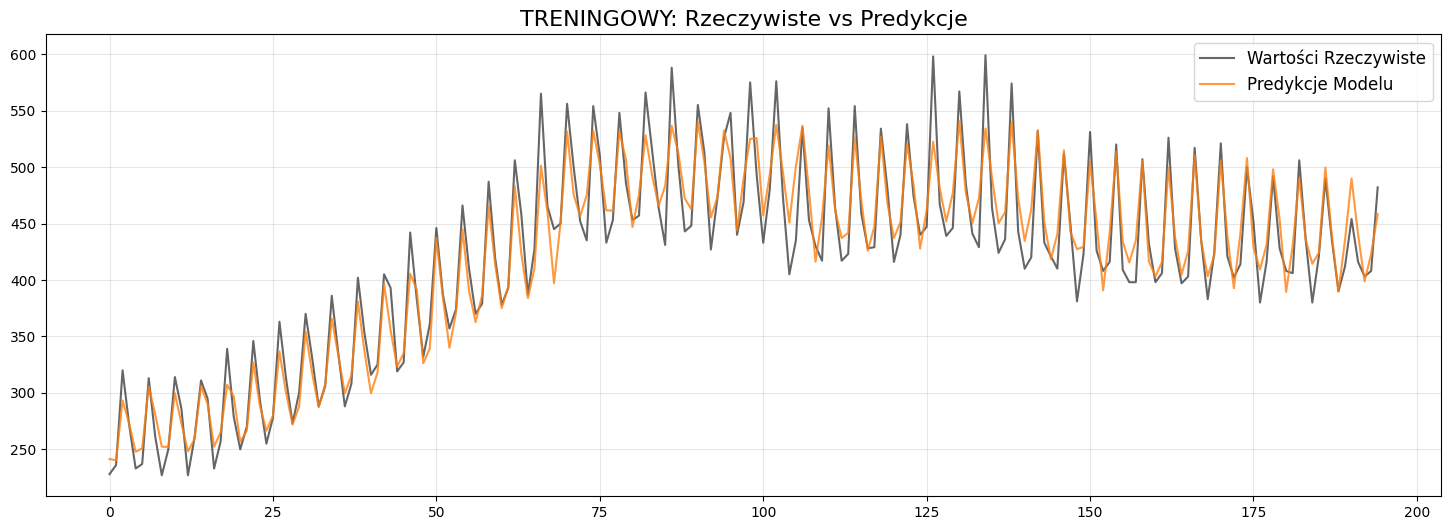

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


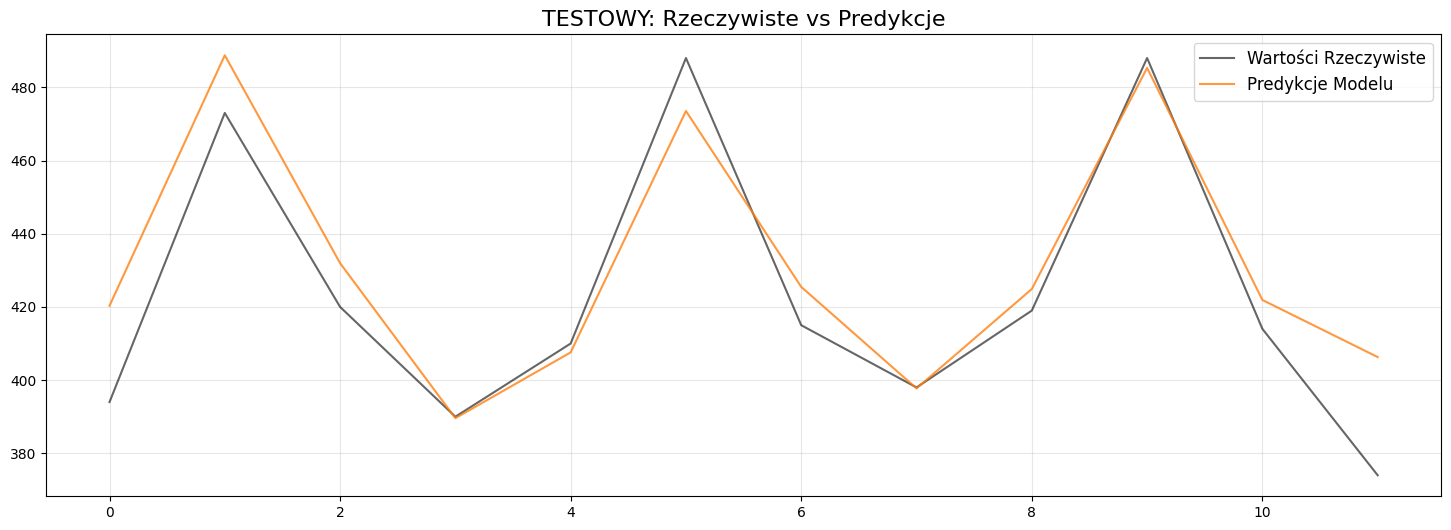

<Sequential name=sequential_35, built=True>

In [162]:
nowy_model(model3, epoki1=100, lr1=0.001, epoki2=400, lr2=0.0001)

Otrzymaliśmy dość dobre dopasowanie
* 500 epok (100 lr = 0.001, 400 lr = 0.0001)

## Model 4

In [163]:
model4 = Sequential()
model4.add(InputLayer((seq_len,1)))
model4.add(GRU(64, return_sequences=True)) # Zwracamy pełną informację dla kolejnej warstwy LSTM
model4.add(GRU(64, return_sequences=True))
model4.add(GRU(64))
model4.add(Dense(16, 'relu'))
model4.add(Dense(8, 'relu'))
model4.add(Dense(1,'linear')) # Wyjście
model4.summary()

Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_37 (GRU)                    │ (None, 5, 64)          │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_38 (GRU)                    │ (None, 5, 64)          │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_39 (GRU)                    │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_92 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_93 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_94 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,969 (249.88 KB)

 Trainable params: 63,969 (249.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 181611.2969 - root_mean_squared_error: 426.1456 - val_loss: 178398.3594 - val_root_mean_squared_error: 422.3723
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 182593.2188 - root_mean_squared_error: 427.3018 - val_loss: 177500.9531 - val_root_mean_squared_error: 421.3086
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 186274.9531 - root_mean_squared_error: 431.5094 - val_loss: 176581.5469 - val_root_mean_squared_error: 420.2161
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 182158.0000 - root_mean_squared_error: 426.7778 - val_loss: 175822.2500 - val_root_mean_squared_error: 419.3116
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 176259.7656 - root_mean_squared_error: 419.8132 - val_loss: 175060.8750 - val_root_mean_squared_error: 418.4028
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 179206.9531 - root_mean_squared_error: 423.3074 - val_loss: 174272.6094 - val_root_mean_squa

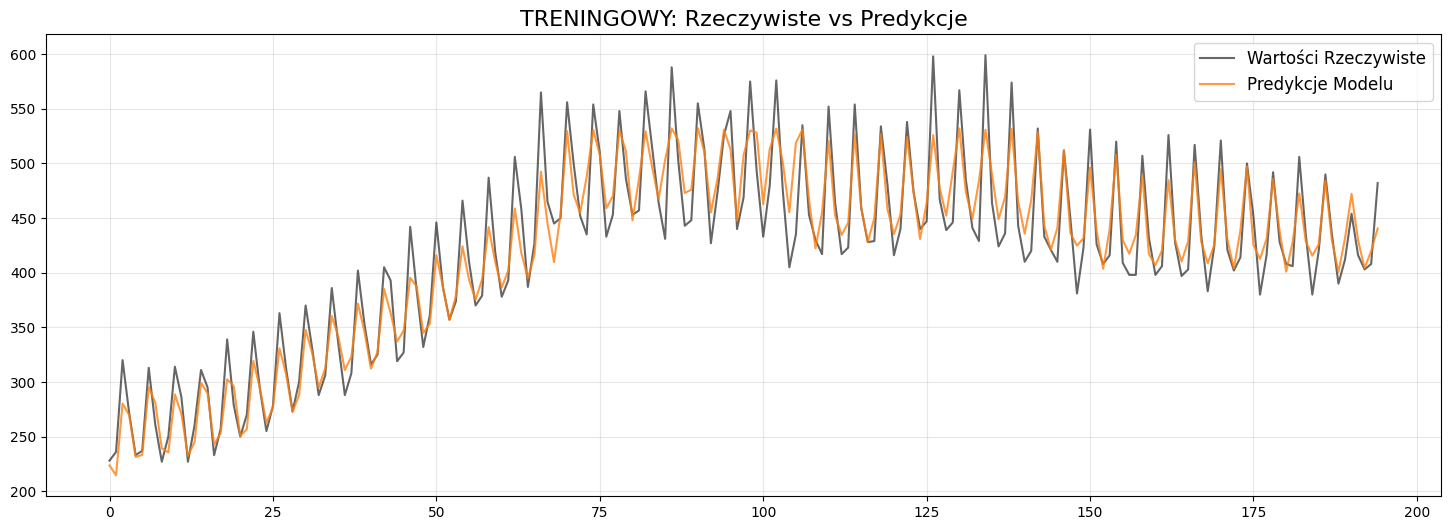

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


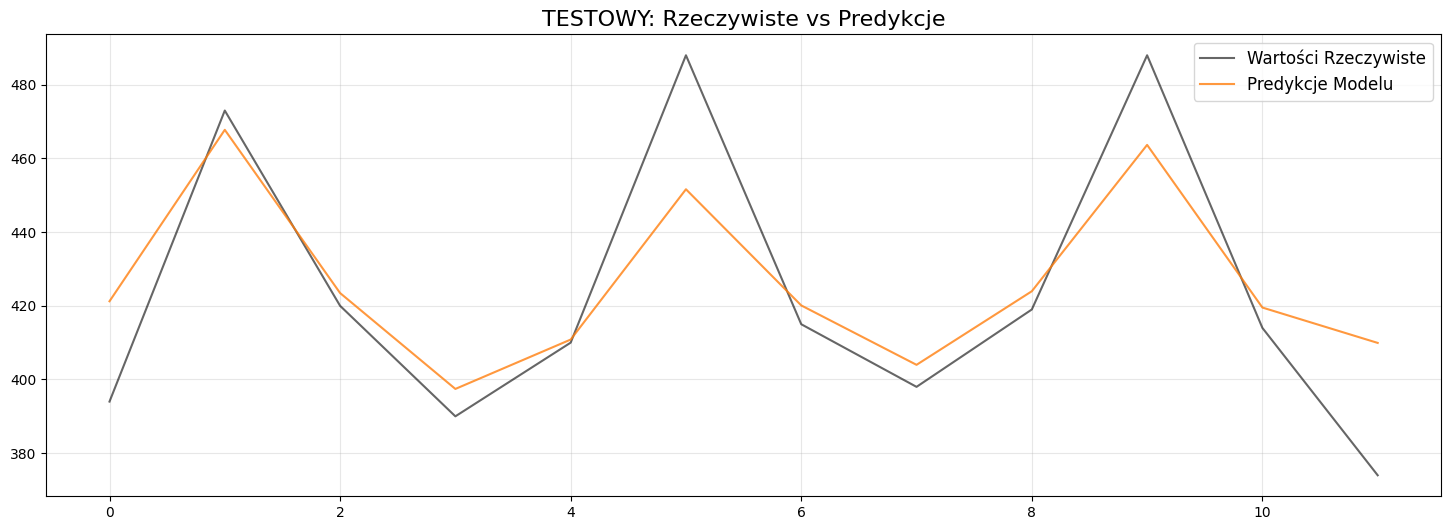

<Sequential name=sequential_36, built=True>

In [165]:
nowy_model(model4, epoki1=100, lr1=0.001, epoki2=300, lr2=0.0001)

## Gorsze dopasowanie względem modelu 3 (pomimo większej liczby parametrów)

## Model 5

In [166]:
model5 = Sequential()
model5.add(InputLayer((seq_len,1)))
model5.add(GRU(64, return_sequences=True, dropout=0.1))

model5.add(GRU(64, dropout=0.1))

model5.add(Dense(16, activation='relu'))
model5.add(Dropout(0.1))

model5.add(Dense(1,'linear')) # Wyjście
model5.summary()

Model: "sequential_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_40 (GRU)                    │ (None, 5, 64)          │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_41 (GRU)                    │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_95 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_96 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,881 (151.88 KB)

 Trainable params: 38,881 (151.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 177749.5469 - root_mean_squared_error: 421.5642 - val_loss: 175876.3906 - val_root_mean_squared_error: 419.3762
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 173795.0625 - root_mean_squared_error: 416.8170 - val_loss: 172631.6875 - val_root_mean_squared_error: 415.4897
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 172864.4531 - root_mean_squared_error: 415.7371 - val_loss: 169701.3281 - val_root_mean_squared_error: 411.9482
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 168466.4688 - root_mean_squared_error: 410.3580 - val_loss: 167198.3906 - val_root_mean_squared_error: 408.8990
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 172571.5938 - root_mean_squared_error: 415.3591 - val_loss: 164950.1875 - val_root_mean_squared_error: 406.1406
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 173107.7812 - root_mean_squared_error: 416.0363 - val_loss: 162775.2344 - val_root_mean_squa

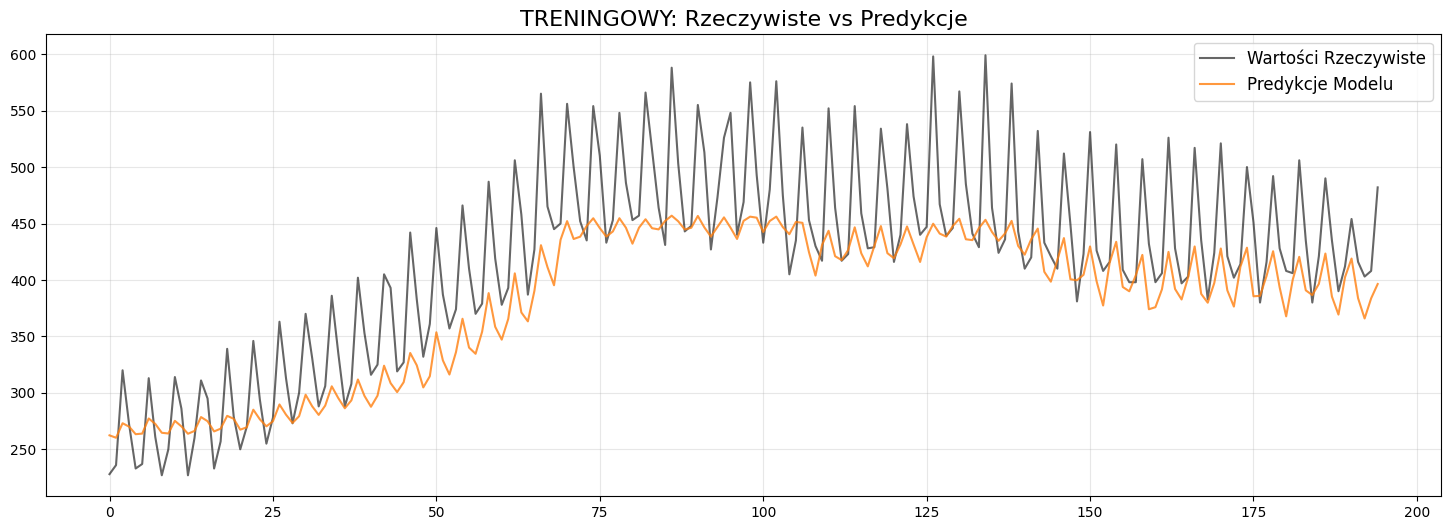

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


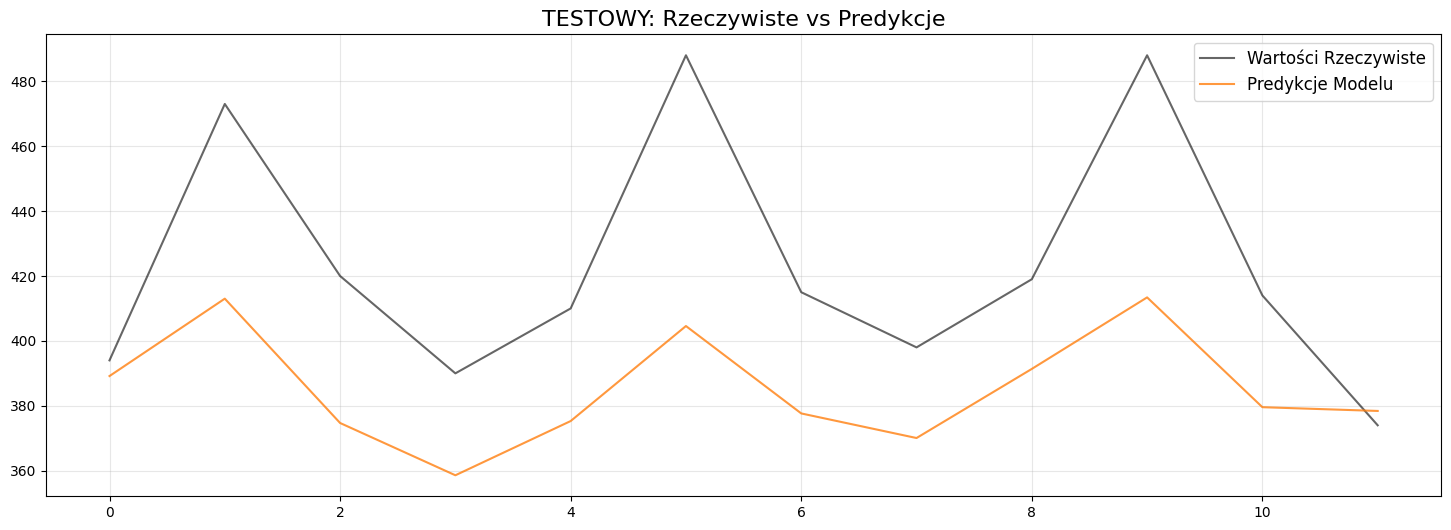

<Sequential name=sequential_37, built=True>

In [167]:
nowy_model(model5, epoki1=100, lr1=0.001, epoki2=300, lr2=0.0001)

BatchNormalization/Dropout pogorszył proces uczenia.

Pomimo podobnej wartości val_root_mean_squared_error: 43.8079, model przyjmuje niepoprawne wartości.

## Model 6

In [168]:
model6 = Sequential()
model6.add(InputLayer((seq_len,1)))
model6.add(GRU(64, return_sequences=True, dropout=0.1))

model6.add(GRU(64, return_sequences=True, dropout=0.1))

model6.add(GRU(32))

model6.add(Dense(16, activation='relu'))
model6.add(Dropout(0.1))

model6.add(Dense(8, activation='relu'))
model6.add(Dropout(0.1))

model6.add(Dense(1,'linear')) # Wyjście
model6.summary()

Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_42 (GRU)                    │ (None, 5, 64)          │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_43 (GRU)                    │ (None, 5, 64)          │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_44 (GRU)                    │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_97 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_98 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_99 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,905 (187.13 KB)

 Trainable params: 47,905 (187.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 184343.5312 - root_mean_squared_error: 429.3464 - val_loss: 178044.5469 - val_root_mean_squared_error: 421.9532
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 185789.4688 - root_mean_squared_error: 430.9414 - val_loss: 176581.4219 - val_root_mean_squared_error: 420.2159
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 178323.3281 - root_mean_squared_error: 422.2779 - val_loss: 175256.1406 - val_root_mean_squared_error: 418.6360
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 177363.2188 - root_mean_squared_error: 421.1004 - val_loss: 174155.9062 - val_root_mean_squared_error: 417.3199
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 178524.2500 - root_mean_squared_error: 422.5152 - val_loss: 173126.6719 - val_root_mean_squared_error: 416.0849
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 173194.7344 - root_mean_squared_error: 416.1389 - val_loss: 172044.8906 - val_root_mean_squa

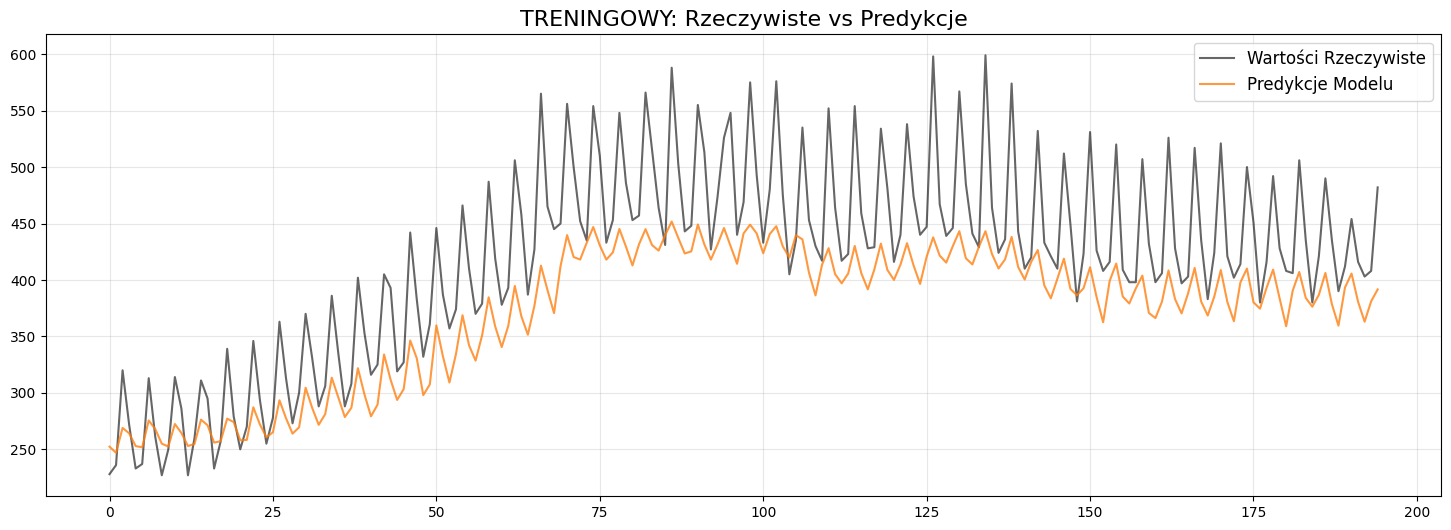

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


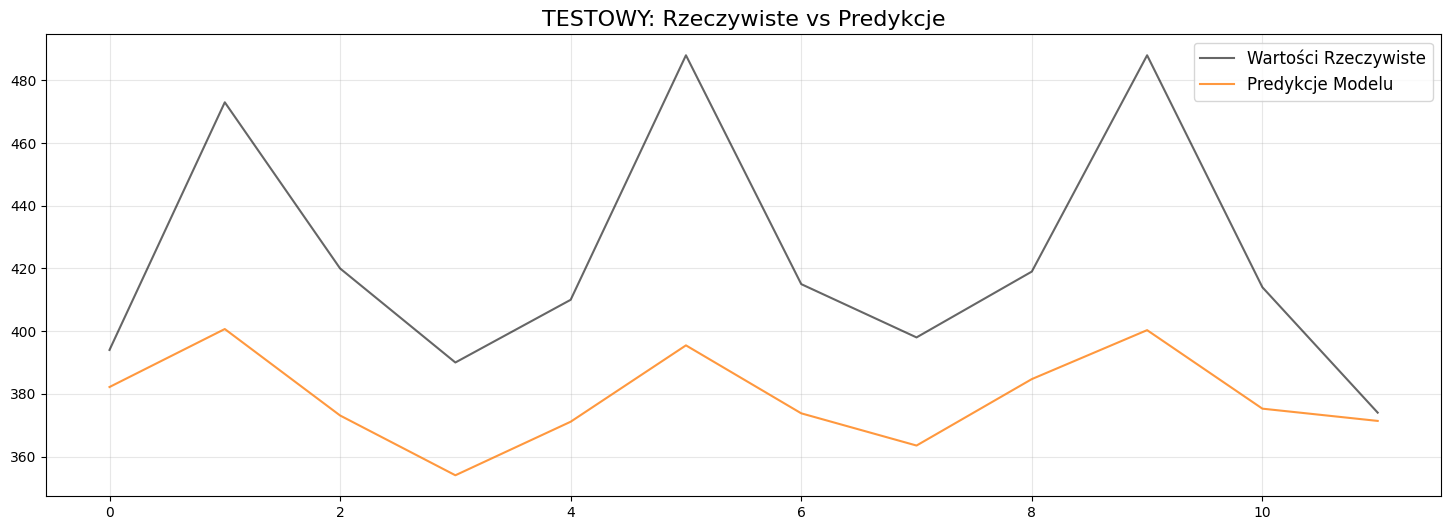

<Sequential name=sequential_38, built=True>

In [169]:
nowy_model(model6, epoki1=200, lr1=0.001, epoki2=400, lr2=0.0001)

Teraz ten sam model ale bez Dropout'u

In [170]:
model6 = Sequential()
model6.add(InputLayer((seq_len,1)))
model6.add(GRU(64, return_sequences=True))

model6.add(GRU(64, return_sequences=True))

model6.add(GRU(32))

model6.add(Dense(16, activation='relu'))

model6.add(Dense(8, activation='relu'))

model6.add(Dense(1,'linear')) # Wyjście
model6.summary()

Model: "sequential_39"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_45 (GRU)                    │ (None, 5, 64)          │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_46 (GRU)                    │ (None, 5, 64)          │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_47 (GRU)                    │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_100 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_101 (Dense)               │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_102 (Dense)               │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,905 (187.13 KB)

 Trainable params: 47,905 (187.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 183457.9062 - root_mean_squared_error: 428.2975 - val_loss: 177887.6719 - val_root_mean_squared_error: 421.7673
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 175234.0312 - root_mean_squared_error: 418.5043 - val_loss: 177085.4375 - val_root_mean_squared_error: 420.8152
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 186692.0625 - root_mean_squared_error: 431.9628 - val_loss: 176371.9531 - val_root_mean_squared_error: 419.9666
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 179275.7188 - root_mean_squared_error: 423.3940 - val_loss: 175759.8750 - val_root_mean_squared_error: 419.2372
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 185587.3281 - root_mean_squared_error: 430.7299 - val_loss: 175169.3281 - val_root_mean_squared_error: 418.5323
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 177746.7188 - root_mean_squared_error: 421.5800 - val_loss: 174572.6719 - val_root_mean_squa

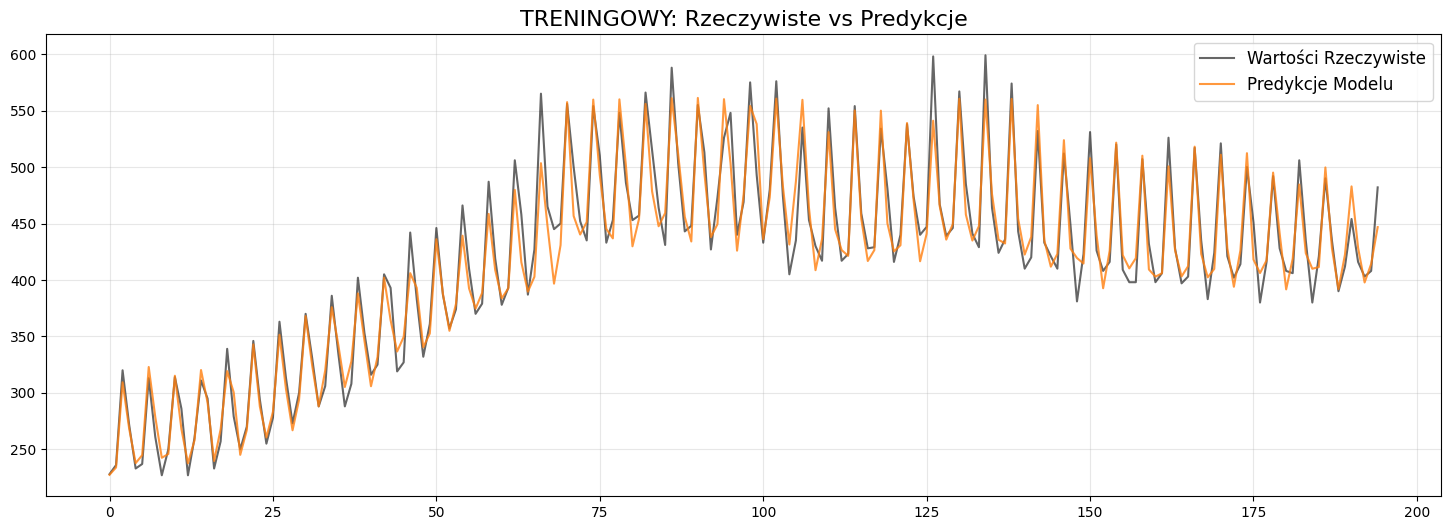

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


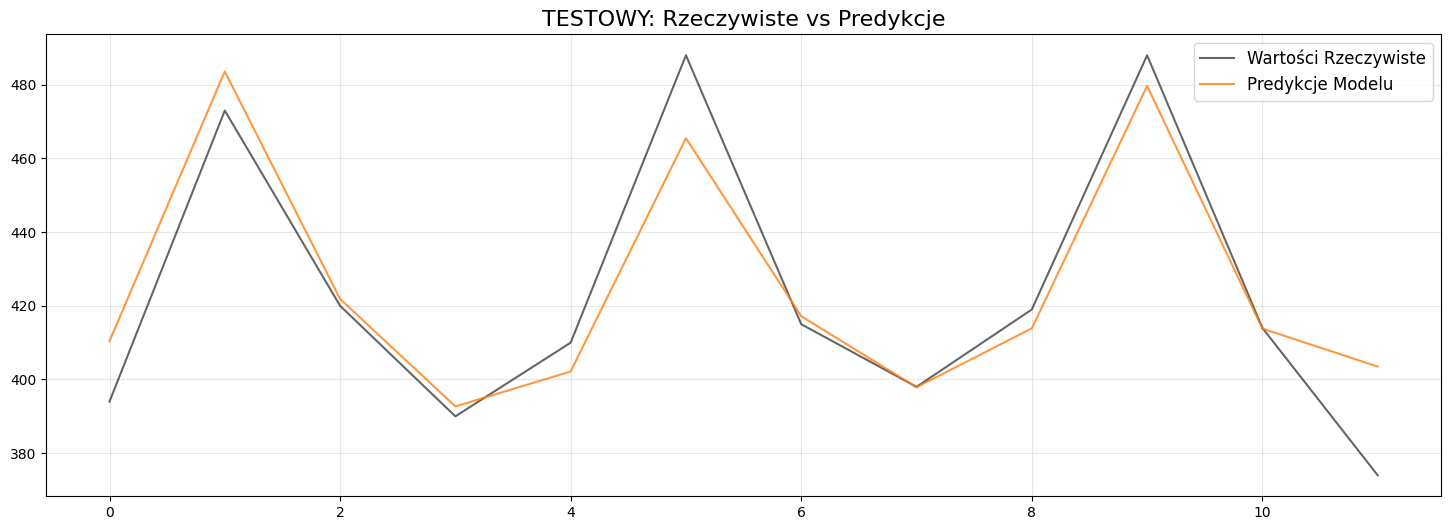

<Sequential name=sequential_39, built=True>

In [171]:
nowy_model(model6, epoki1=200, lr1=0.001, epoki2=400, lr2=0.0001)

O wiele lepsze, zgodne z rzeczywistością prognozy. Można spróbować ograniczyć proces uczenia do 200 + 200 epok.

## Wygenerowany zbiór danych - funkcja trygonometryczna + szum
Stwórzmy syntetyczny zbiór danych

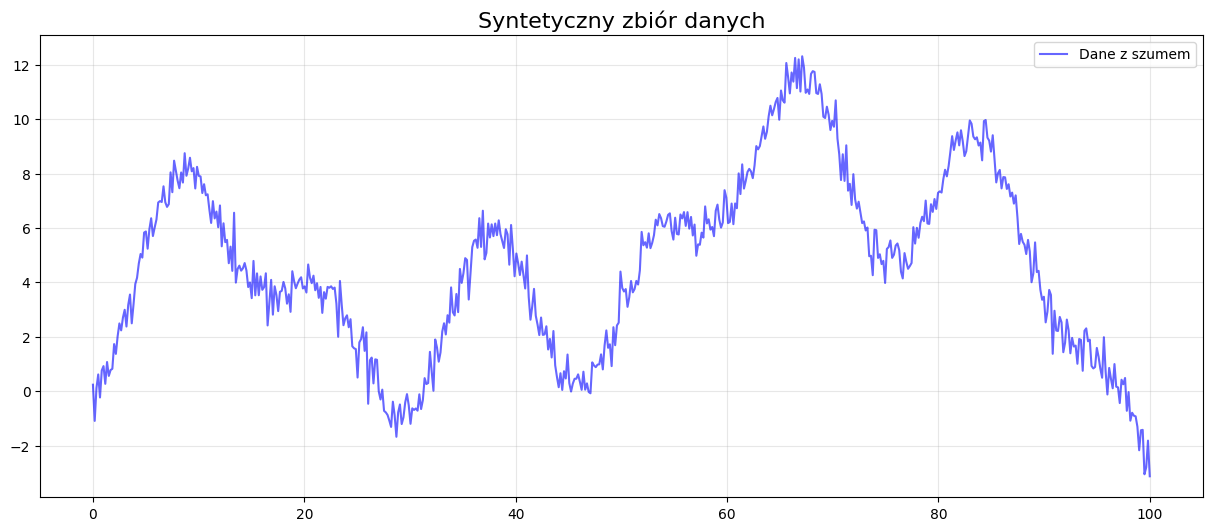

In [126]:
# Generowanie zbioru danych
def generuj_tryg_z_szumem(n_probek=1000, amplituda = 1 , od=0, do = 100, okres = 1, alpha = 1/2, fun_trend = None):

    x = np.linspace(od, do, n_probek)

    # Składowe
    y_tryg = (np.sin(okres*x) * amplituda)**2 * 2*np.cos(1/2*okres*x) * amplituda

    szum = np.random.normal(loc=0, scale=1, size=n_probek) # średnia = 0, odch_std = 1

    # Dodanie szumu do sygnału
    y_szum = alpha*y_tryg + (1-alpha)*szum

    # Dodanie trendu
    if fun_trend is not None:
        # Obliczamy wartości trendu dla każdego x i dodajemy do wyniku
        trend_wart = fun_trend(x)
        y_szum = y_szum + trend_wart

    return x, y_szum

def moj_trend(x):
  return -1/400*x**2 + 1/4*x

x_sin, y_sin = generuj_tryg_z_szumem(n_probek=600, amplituda = 2 , od=0, do = 100, okres = 1/6, alpha = 0.5, fun_trend=moj_trend)


plt.figure(figsize=(15, 6))
plt.plot(x_sin, y_sin, label='Dane z szumem', color='blue', alpha=0.6)
plt.title('Syntetyczny zbiór danych', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [127]:
# Tworzymy sekwencje dla RNN
def rnn_sequence_np(dane, seq_len):

    X, y =  [], []
    for i in range(len(dane) - seq_len):
        seq = [[x] for x in dane[i : i + seq_len]]
        X.append(seq)
        label = dane[i + seq_len]
        y.append(label)
    return np.array(X), np.array(y)

# Długość sekwencji
# Chcemy brać 5 obserwacji i przewidywać 6

seq_len = 5
# Następnie przechodzimy o 1 krok w prawo i wykorzystujemy 6. prognozowaną obserwację do kolejnej prognozy

X, y = rnn_sequence_np(y_sin, seq_len=seq_len)

data_len = X.shape[0]
test_len = int( 0.2*data_len )
val_len = int( 0.1*data_len )

X_train, y_train = X[:data_len-test_len-val_len], y[:data_len-test_len-val_len] # zbiór uczący
X_val, y_val = X[data_len-val_len-test_len:data_len-test_len], y[data_len-val_len-test_len:data_len-test_len] # 6 obserwacji do zbioru walidacyjnego
X_test, y_test = X[data_len-test_len:], y[data_len-test_len:] # zbiór testowy

In [128]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape

((417, 5, 1), (417,), (59, 5, 1), (59,), (119, 5, 1))

In [129]:
def nowy_model(model, epoki1=100, lr1=0.001, epoki2=100, lr2=0.0001):

    model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=lr1), metrics=[RootMeanSquaredError()])
    model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs = epoki1)

    model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=lr2), metrics=[RootMeanSquaredError()])
    model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs = epoki2)

    predykcje_train = model.predict(X_train).flatten()
    wyniki_train = pd.DataFrame(data={'Predykcje': predykcje_train, 'Rzeczywiste': y_train}).reset_index(drop=True)

    plt.figure(figsize=(18, 6))
    plt.title('TRENINGOWY: Rzeczywiste vs Predykcje', fontsize=16)
    plt.plot(wyniki_train['Rzeczywiste'], label='Wartości Rzeczywiste', color='black', alpha=0.6)
    plt.plot(wyniki_train['Predykcje'], label='Predykcje Modelu', color='#ff7f0e', alpha=0.8)
    plt.legend(loc='best', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

    predykcje_test = model.predict(X_test).flatten()
    wyniki_test = pd.DataFrame(data={'Predykcje': predykcje_test, 'Rzeczywiste': y_test}).reset_index(drop=True)

    plt.figure(figsize=(18, 6))
    plt.title('TESTOWY: Rzeczywiste vs Predykcje', fontsize=16)
    plt.plot(wyniki_test['Rzeczywiste'], label='Wartości Rzeczywiste', color='black', alpha=0.6)
    plt.plot(wyniki_test['Predykcje'], label='Predykcje Modelu', color='#ff7f0e', alpha=0.8)
    plt.legend(loc='best', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

    return model

In [130]:
# Tworzymy model1
model1 = Sequential()
model1.add(InputLayer((seq_len,1)))
model1.add(LSTM(64))
model1.add(Dense(8, 'relu'))
model1.add(Dense(1,'linear')) # Wyjście

model1.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_13 (LSTM)                  │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,425 (68.07 KB)

 Trainable params: 17,425 (68.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 26.6667 - root_mean_squared_error: 5.1529 - val_loss: 16.5585 - val_root_mean_squared_error: 4.0692
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 13.5953 - root_mean_squared_error: 3.6745 - val_loss: 4.2088 - val_root_mean_squared_error: 2.0515
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.8308 - root_mean_squared_error: 2.1920 - val_loss: 1.2788 - val_root_mean_squared_error: 1.1308
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.4777 - root_mean_squared_error: 1.8640 - val_loss: 1.3052 - val_root_mean_squared_error: 1.1425
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.3542 - root_mean_squared_error: 1.5327 - val_loss: 0.5942 - val_root_mean_squared_error: 0.7708
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.6992 - root_mean_squared_error: 1.3028 - val_loss: 0.4764 - val_root_mean_squared_error: 0.6902
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - los

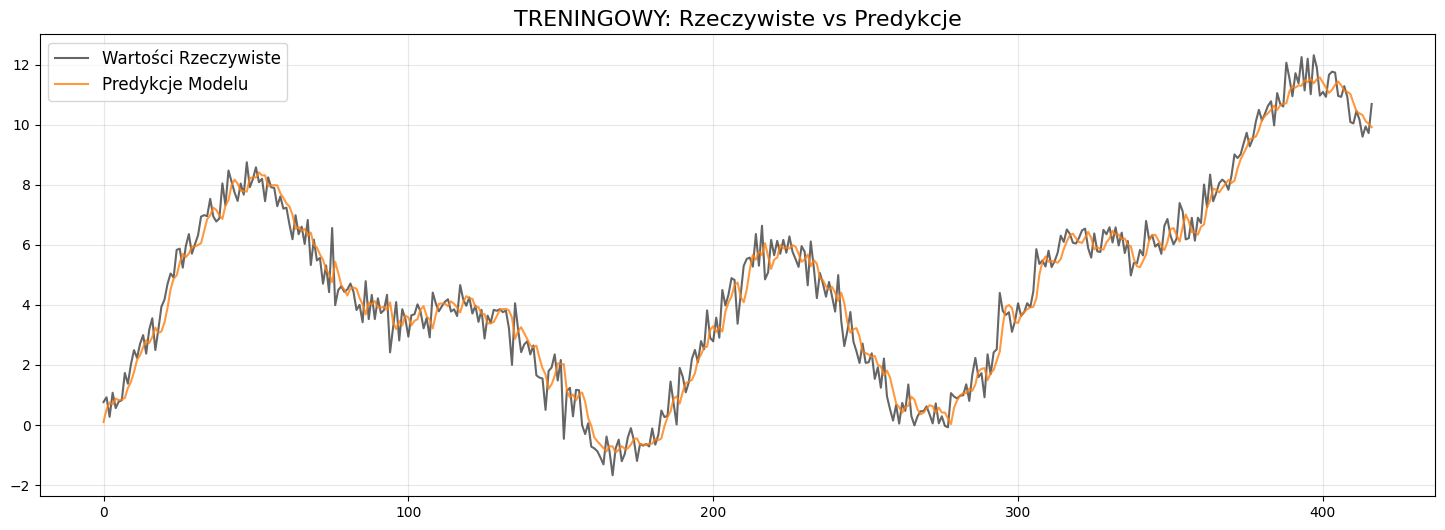

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


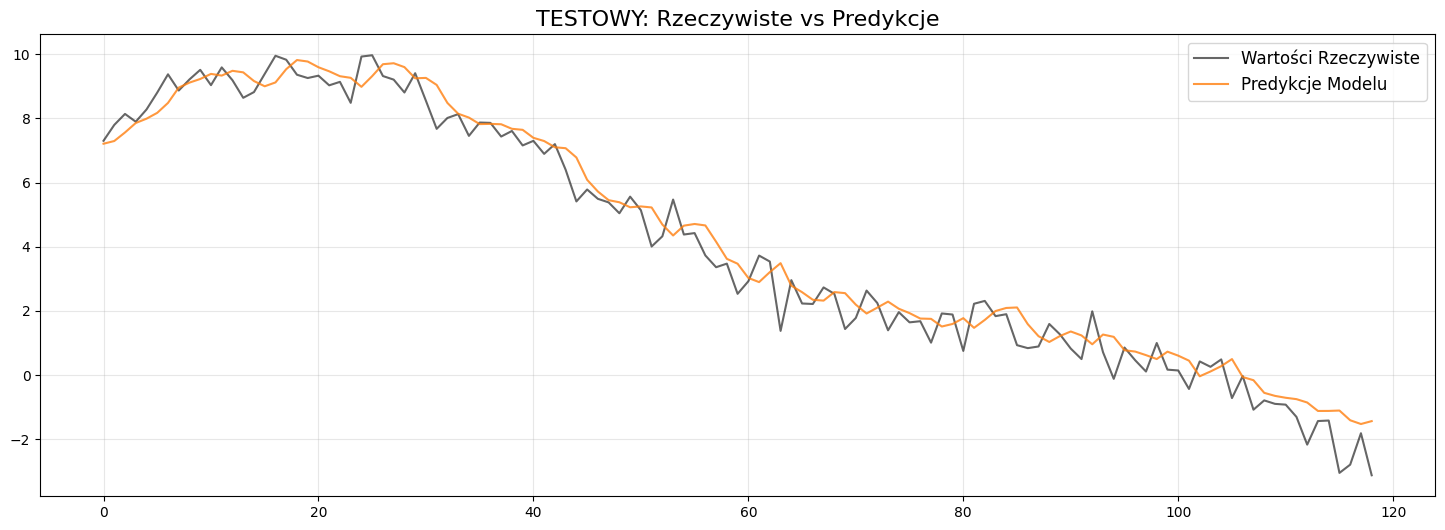

<Sequential name=sequential_24, built=True>

In [131]:
nowy_model(model=model1, epoki1=50, lr1 = 0.001, epoki2=100, lr2 = 0.0001)

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 5, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,105 (199.63 KB)

 Trainable params: 51,105 (199.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 25.7483 - root_mean_squared_error: 5.0702 - val_loss: 10.7797 - val_root_mean_squared_error: 3.2832
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.4675 - root_mean_squared_error: 2.7107 - val_loss: 2.0357 - val_root_mean_squared_error: 1.4268
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.3611 - root_mean_squared_error: 2.0874 - val_loss: 0.9955 - val_root_mean_squared_error: 0.9978
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.0979 - root_mean_squared_error: 1.7594 - val_loss: 0.6612 - val_root_mean_squared_error: 0.8131
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.7870 - root_mean_squared_error: 1.3341 - val_loss: 0.5671 - val_root_mean_squared_error: 0.7531
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.0622 - root_mean_squared_error: 1.0297 - val_loss: 0.5081 - val_root_mean_squared_error: 0.7128
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - los

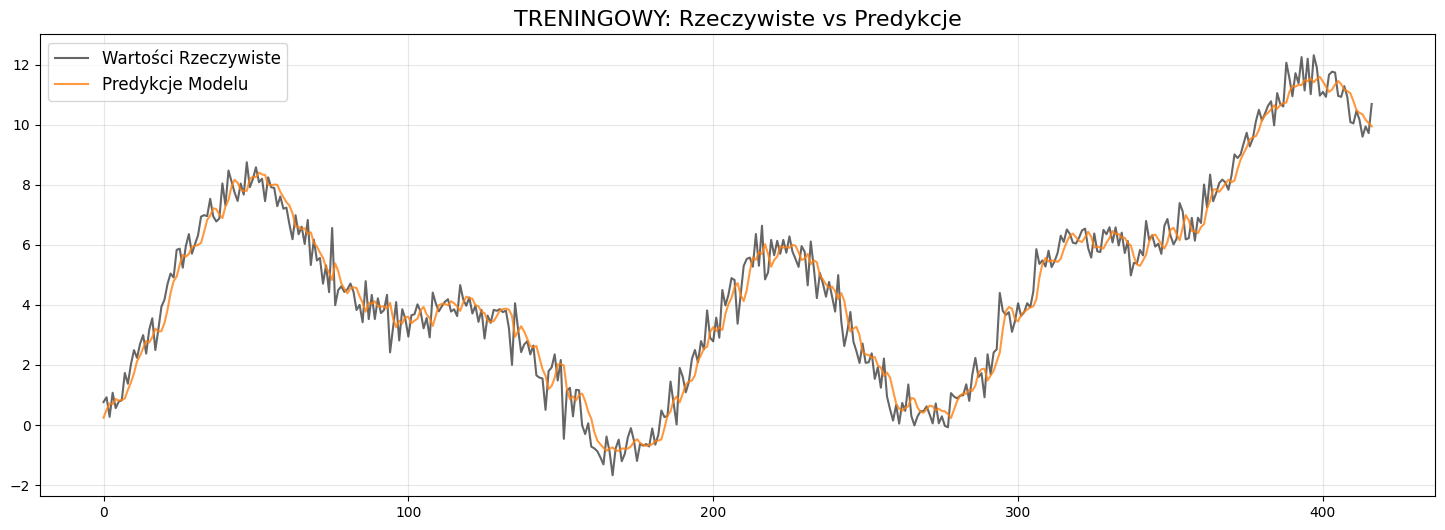

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


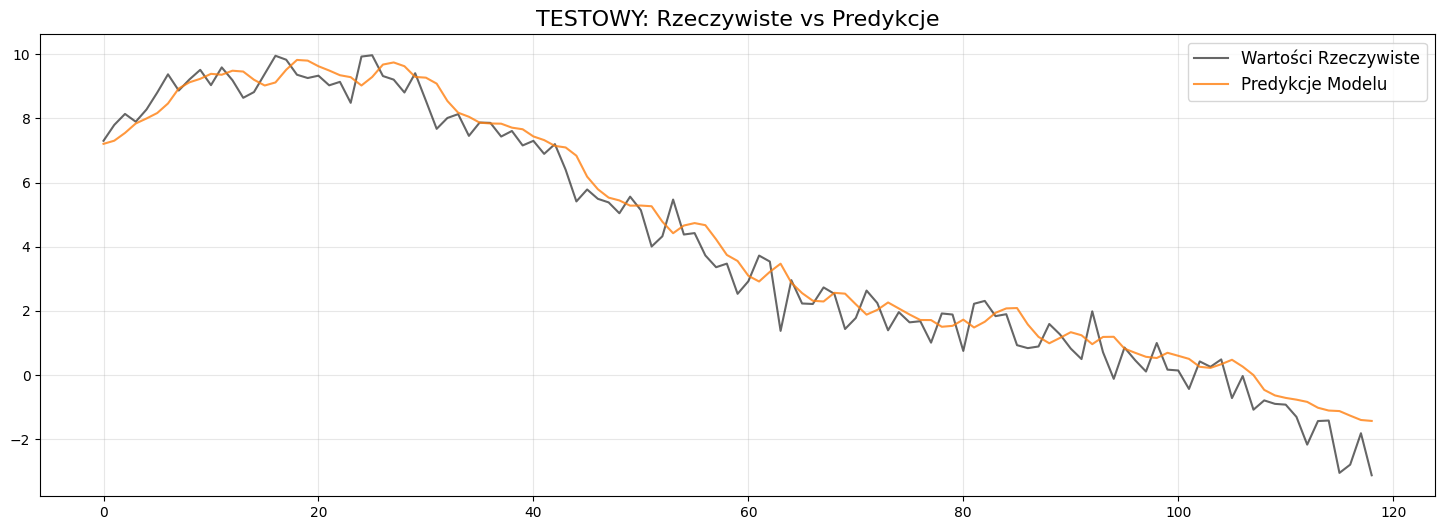

<Sequential name=sequential_25, built=True>

In [132]:
# Tworzymy model2
model2 = Sequential()
model2.add(InputLayer((seq_len,1)))
model2.add(LSTM(64, return_sequences=True)) # Zwracamy pełną informację dla kolejnej warstwy LSTM
model2.add(LSTM(64))
model2.add(Dense(16, 'relu'))
model2.add(Dense(8, 'relu'))
model2.add(Dense(1,'linear')) # Wyjście

model2.summary()

nowy_model(model=model2, epoki1=50, lr1 = 0.001, epoki2=100, lr2 = 0.0001)

Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_23 (GRU)                    │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,049 (54.88 KB)

 Trainable params: 14,049 (54.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 35.1766 - root_mean_squared_error: 5.9273 - val_loss: 38.6633 - val_root_mean_squared_error: 6.2180
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 30.2441 - root_mean_squared_error: 5.4960 - val_loss: 37.3894 - val_root_mean_squared_error: 6.1147
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 27.2278 - root_mean_squared_error: 5.2177 - val_loss: 24.5065 - val_root_mean_squared_error: 4.9504
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 19.7257 - root_mean_squared_error: 4.4230 - val_loss: 8.3244 - val_root_mean_squared_error: 2.8852
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7.4277 - root_mean_squared_error: 2.7164 - val_loss: 1.3701 - val_root_mean_squared_error: 1.1705
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4.2874 - root_mean_squared_error: 2.0631 - val_loss: 0.8282 - val_root_mean_squared_error: 0.9101
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss

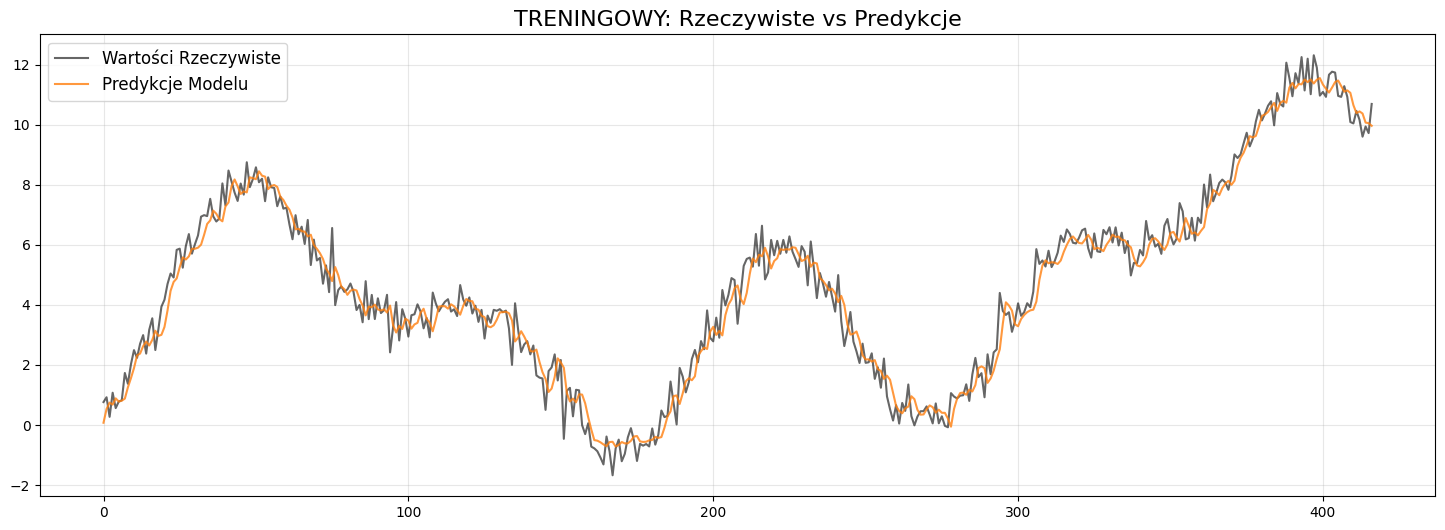

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


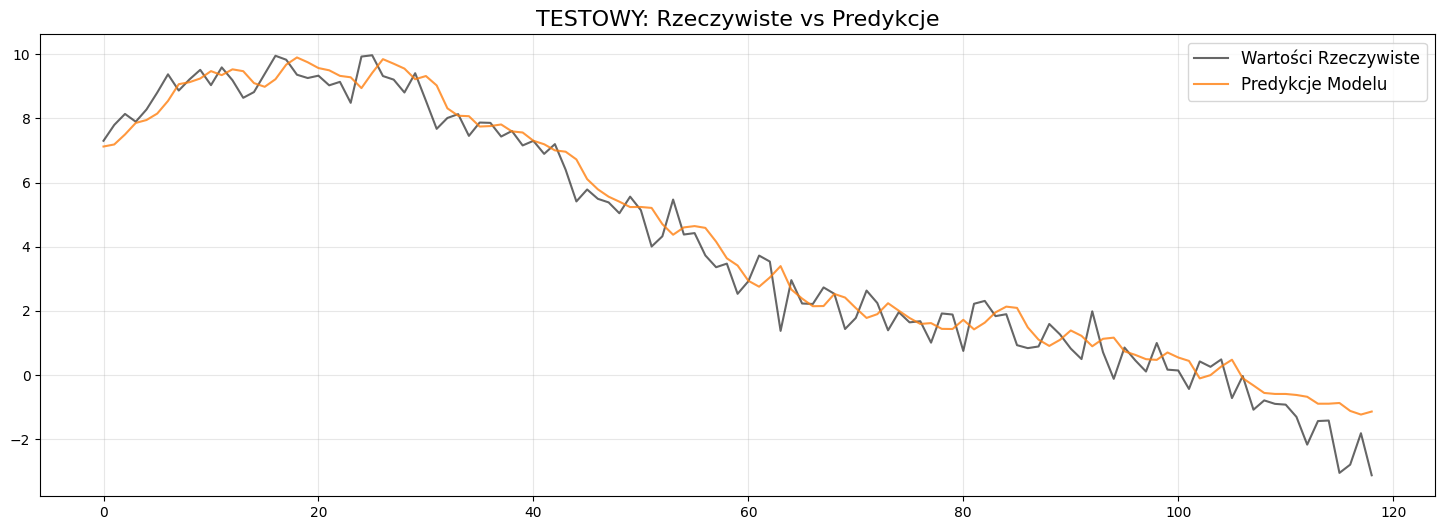

<Sequential name=sequential_26, built=True>

In [133]:
# Tworzymy model3
model3 = Sequential()
model3.add(InputLayer((seq_len,1)))
model3.add(GRU(64))
model3.add(Dense(16, 'relu'))
model3.add(Dense(8, 'relu'))
model3.add(Dense(1,'linear')) # Wyjście

model3.summary()

nowy_model(model=model3, epoki1=50, lr1 = 0.001, epoki2=100, lr2 = 0.0001)

Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_24 (GRU)                    │ (None, 5, 64)          │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_25 (GRU)                    │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,009 (152.38 KB)

 Trainable params: 39,009 (152.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 23.4859 - root_mean_squared_error: 4.8283 - val_loss: 7.9010 - val_root_mean_squared_error: 2.8109
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6.1596 - root_mean_squared_error: 2.4773 - val_loss: 1.4421 - val_root_mean_squared_error: 1.2009
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.7775 - root_mean_squared_error: 2.1842 - val_loss: 1.0854 - val_root_mean_squared_error: 1.0418
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.7768 - root_mean_squared_error: 1.6648 - val_loss: 0.7172 - val_root_mean_squared_error: 0.8469
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.7659 - root_mean_squared_error: 1.3277 - val_loss: 0.5887 - val_root_mean_squared_error: 0.7672
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.2237 - root_mean_squared_error: 1.1042 - val_loss: 0.3734 - val_root_mean_squared_error: 0.6111
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss

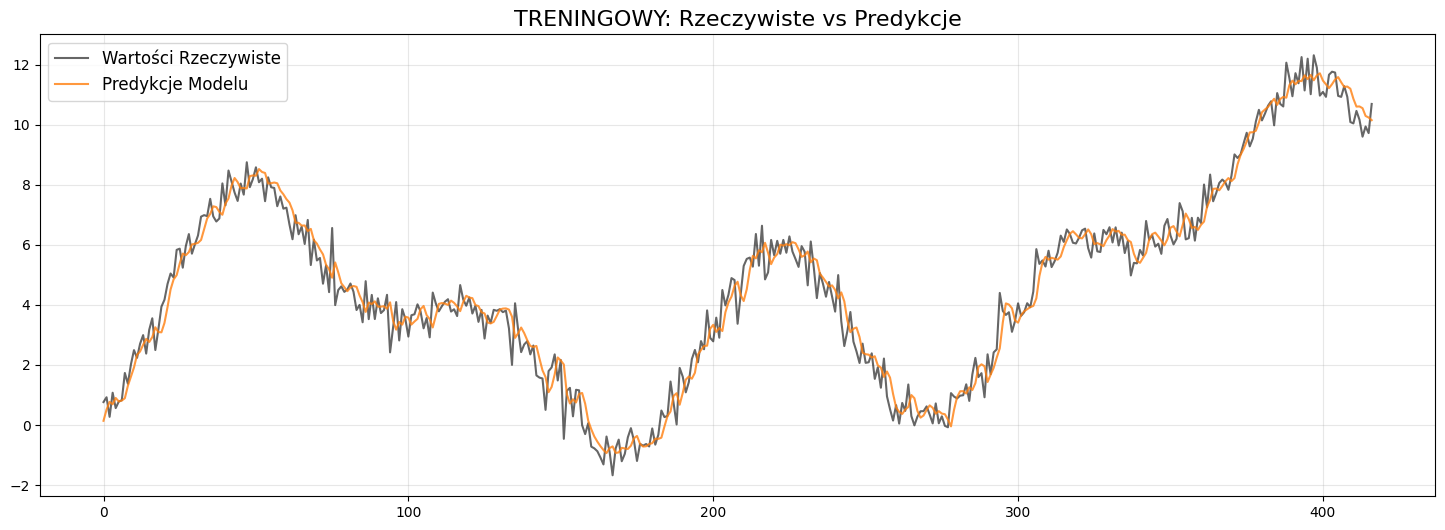

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


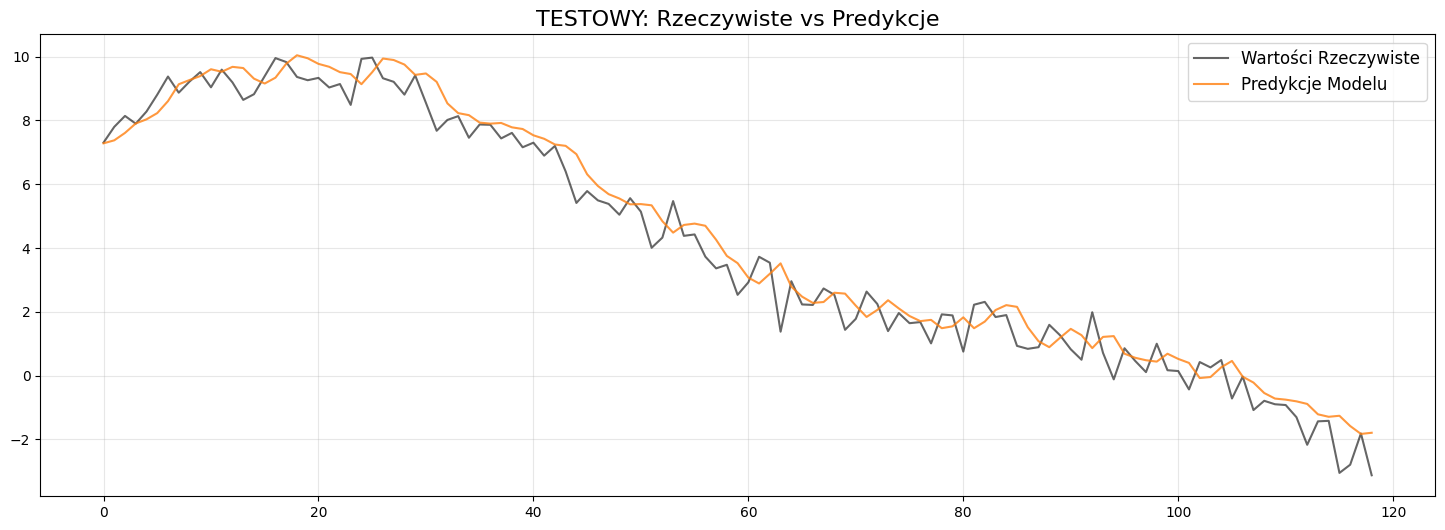

<Sequential name=sequential_27, built=True>

In [134]:
# Tworzymy model4
model4 = Sequential()
model4.add(InputLayer((seq_len,1)))
model4.add(GRU(64, return_sequences=True)) # Zwracamy pełną informację dla kolejnej warstwy LSTM
model4.add(GRU(64))
model4.add(Dense(16, 'relu'))
model4.add(Dense(8, 'relu'))
model4.add(Dense(1,'linear')) # Wyjście

model4.summary()

nowy_model(model=model4, epoki1=50, lr1 = 0.001, epoki2=100, lr2 = 0.0001)

## Dropout

Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_26 (GRU)                    │ (None, 5, 64)          │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_27 (GRU)                    │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,009 (152.38 KB)

 Trainable params: 39,009 (152.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 20.0268 - root_mean_squared_error: 4.4667 - val_loss: 2.1597 - val_root_mean_squared_error: 1.4696
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6.9448 - root_mean_squared_error: 2.6343 - val_loss: 1.6218 - val_root_mean_squared_error: 1.2735
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.5878 - root_mean_squared_error: 2.5644 - val_loss: 1.0196 - val_root_mean_squared_error: 1.0098
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.0220 - root_mean_squared_error: 2.0042 - val_loss: 0.5466 - val_root_mean_squared_error: 0.7393
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.3361 - root_mean_squared_error: 2.0775 - val_loss: 0.3807 - val_root_mean_squared_error: 0.6170
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.1038 - root_mean_squared_error: 2.0243 - val_loss: 0.9646 - val_root_mean_squared_error: 0.9821
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss

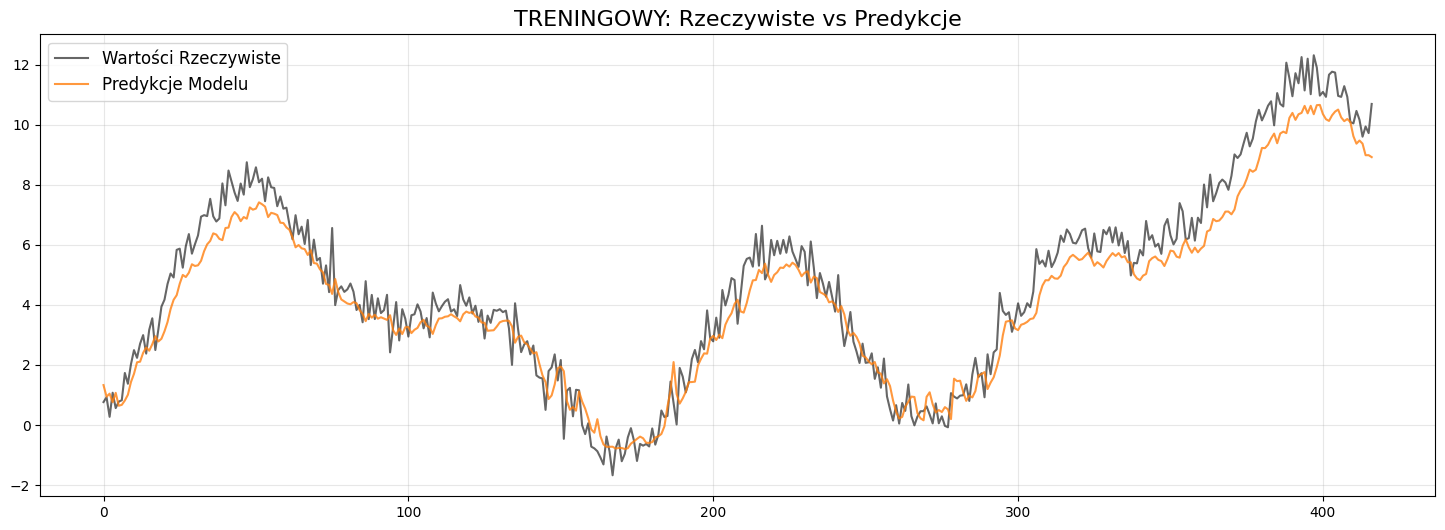

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


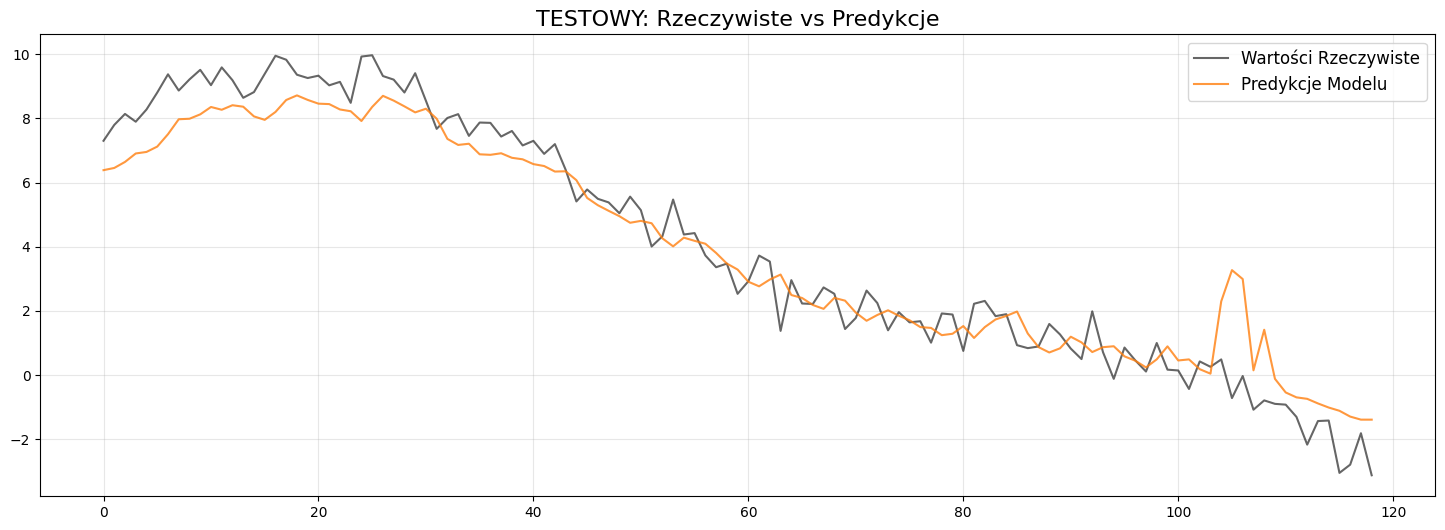

<Sequential name=sequential_28, built=True>

In [135]:
# Tworzymy model4
model5 = Sequential()
model5.add(InputLayer((seq_len,1)))
model5.add(GRU(64, return_sequences=True, dropout=0.1)) # Zwracamy pełną informację dla kolejnej warstwy GRU
model5.add(GRU(64, dropout=0.1))
model5.add(Dense(16, 'relu'))
model5.add(Dense(8, 'relu'))
model5.add(Dense(1,'linear')) # Wyjście

model5.summary()

nowy_model(model=model5, epoki1=50, lr1 = 0.001, epoki2=100, lr2 = 0.0001)

Zdecydowanie gorsze wyniki względem poprzednich modeli

Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_28 (GRU)                    │ (None, 5, 64)          │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_29 (GRU)                    │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,353 (149.82 KB)

 Trainable params: 38,353 (149.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 23.3008 - root_mean_squared_error: 4.8069 - val_loss: 3.3553 - val_root_mean_squared_error: 1.8317
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.7942 - root_mean_squared_error: 2.6028 - val_loss: 1.4980 - val_root_mean_squared_error: 1.2239
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.6520 - root_mean_squared_error: 2.3760 - val_loss: 0.8758 - val_root_mean_squared_error: 0.9358
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.5960 - root_mean_squared_error: 2.1389 - val_loss: 0.6968 - val_root_mean_squared_error: 0.8347
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.1916 - root_mean_squared_error: 2.0412 - val_loss: 0.5614 - val_root_mean_squared_error: 0.7493
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.3925 - root_mean_squared_error: 1.8336 - val_loss: 0.4328 - val_root_mean_squared_error: 0.6579
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss

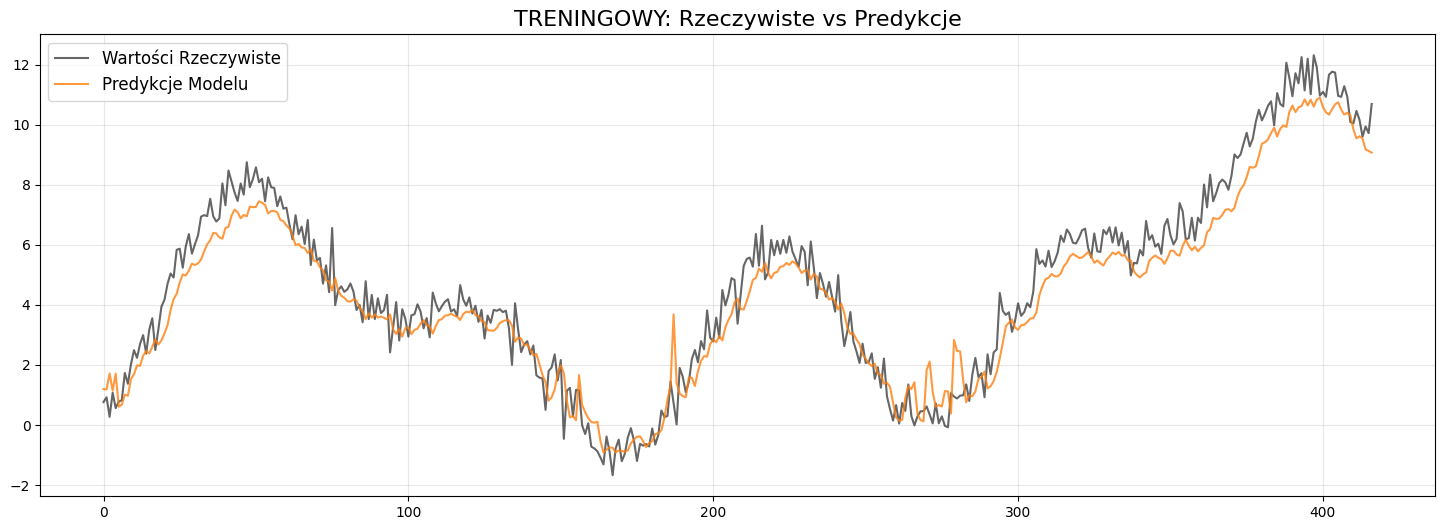

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


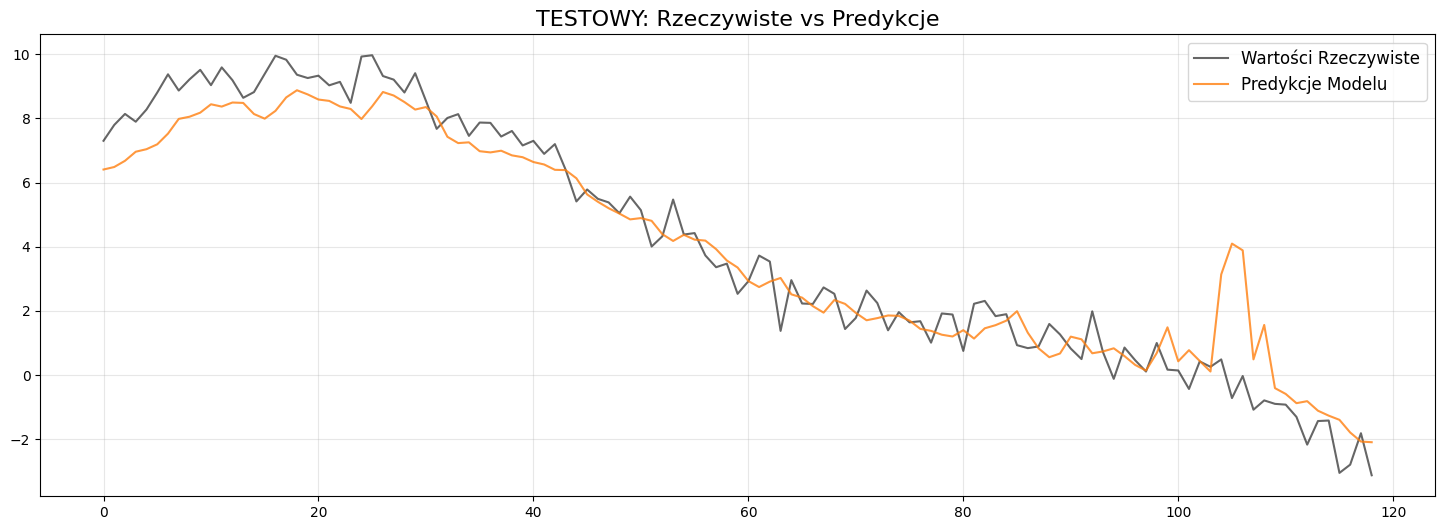

<Sequential name=sequential_29, built=True>

In [136]:
# Tworzymy model4
model5 = Sequential()
model5.add(InputLayer((seq_len,1)))
model5.add(GRU(64, return_sequences=True, dropout=0.1)) # Zwracamy pełną informację dla kolejnej warstwy LSTM
model5.add(GRU(64, dropout=0.1))
model5.add(Dense(8, 'relu'))
model5.add(Dense(1,'linear')) # Wyjście

model5.summary()

nowy_model(model=model5, epoki1=50, lr1 = 0.001, epoki2=100, lr2 = 0.00003)

Zdecydowanie gorsze wyniki względem poprzednich modeli

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_30 (GRU)                    │ (None, 5, 64)          │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_31 (GRU)                    │ (None, 5, 32)          │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_32 (GRU)                    │ (None, 16)             │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,817 (96.94 KB)

 Trainable params: 24,817 (96.94 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 26.3905 - root_mean_squared_error: 5.1322 - val_loss: 15.9965 - val_root_mean_squared_error: 3.9996
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 13.3533 - root_mean_squared_error: 3.6536 - val_loss: 6.9670 - val_root_mean_squared_error: 2.6395
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.4658 - root_mean_squared_error: 3.0755 - val_loss: 2.9226 - val_root_mean_squared_error: 1.7096
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.3261 - root_mean_squared_error: 2.8785 - val_loss: 2.1970 - val_root_mean_squared_error: 1.4822
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 6.4961 - root_mean_squared_error: 2.5422 - val_loss: 1.7301 - val_root_mean_squared_error: 1.3153
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.5966 - root_mean_squared_error: 2.5646 - val_loss: 1.6737 - val_root_mean_squared_error: 1.2937
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - lo

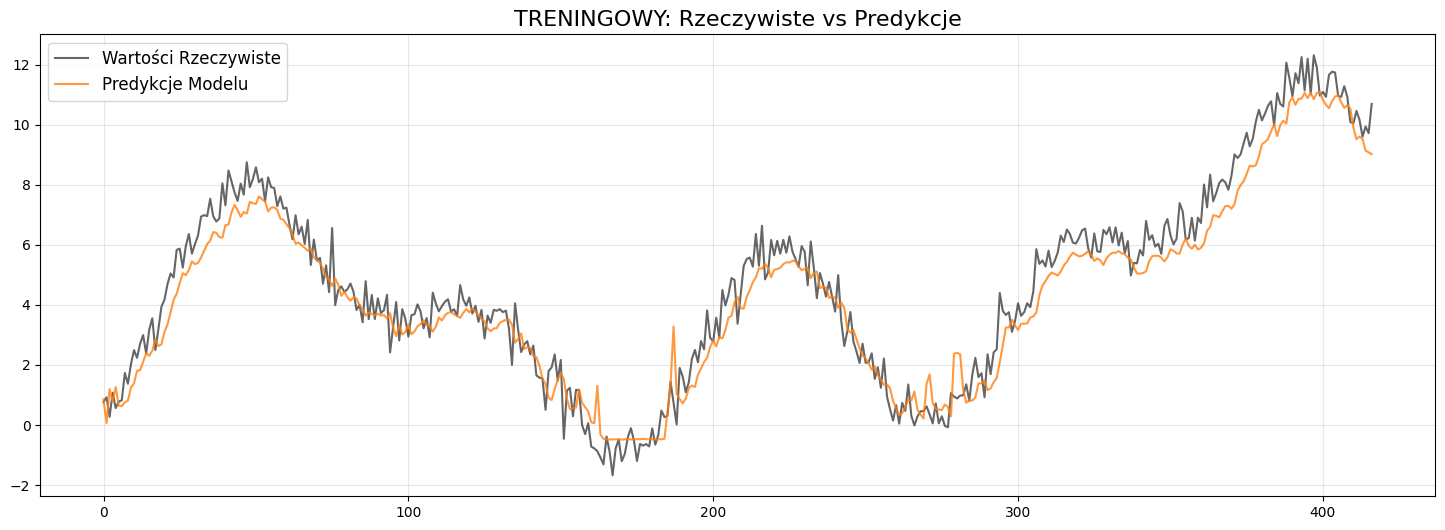

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


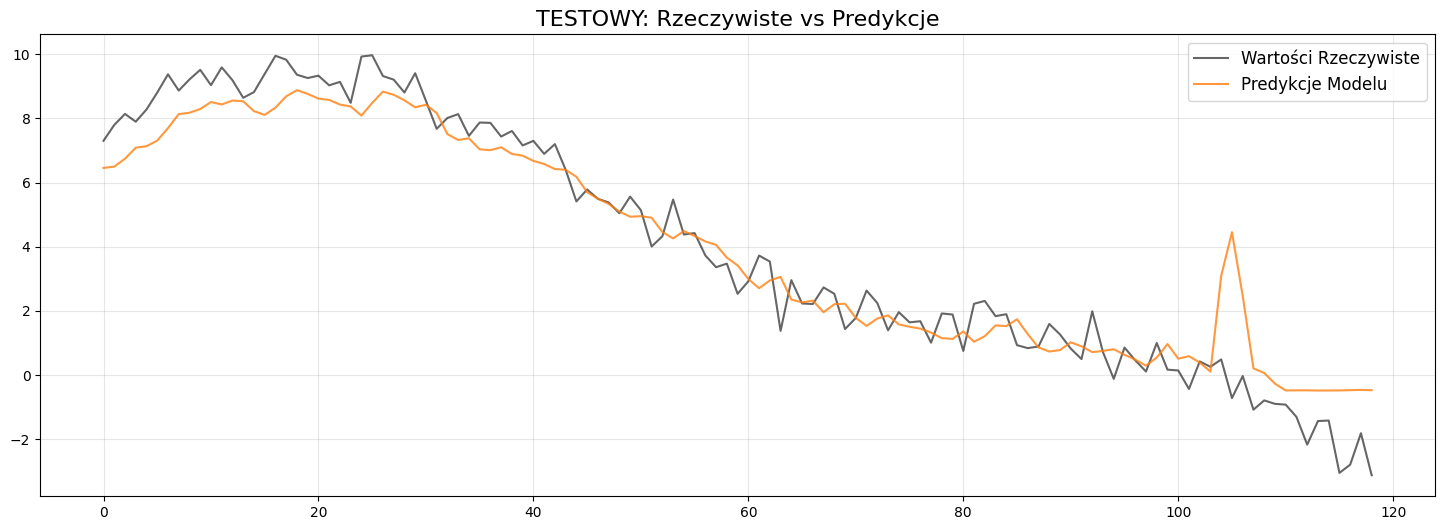

<Sequential name=sequential_30, built=True>

In [137]:
# Tworzymy model4
model5 = Sequential()
model5.add(InputLayer((seq_len,1)))
model5.add(GRU(64, return_sequences=True, dropout=0.1))
model5.add(GRU(32,return_sequences=True, dropout=0.1))
model5.add(GRU(16, dropout=0.1))
model5.add(Dense(8, 'relu'))
model5.add(Dense(1,'linear')) # Wyjście

model5.summary()

nowy_model(model=model5, epoki1=50, lr1 = 0.001, epoki2=100, lr2 = 0.0001)

## Dodatek: CNN

Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_7 (Conv1D)               │ (None, 5, 64)          │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 4, 64)          │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 8)              │         2,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,513 (41.07 KB)

 Trainable params: 10,513 (41.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - loss: 35.9601 - root_mean_squared_error: 5.9418 - val_loss: 4.5804 - val_root_mean_squared_error: 2.1402
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.1679 - root_mean_squared_error: 1.4490 - val_loss: 3.0326 - val_root_mean_squared_error: 1.7414
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.1150 - root_mean_squared_error: 1.0383 - val_loss: 0.5757 - val_root_mean_squared_error: 0.7587
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6878 - root_mean_squared_error: 0.8243 - val_loss: 0.6799 - val_root_mean_squared_error: 0.8245
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4252 - root_mean_squared_error: 0.6518 - val_loss: 0.4989 - val_root_mean_squared_error: 0.7064
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4431 - root_mean_squared_error: 0.6642 - val_loss: 0.4993 - val_root_mean_squared_error: 0.7066
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss:

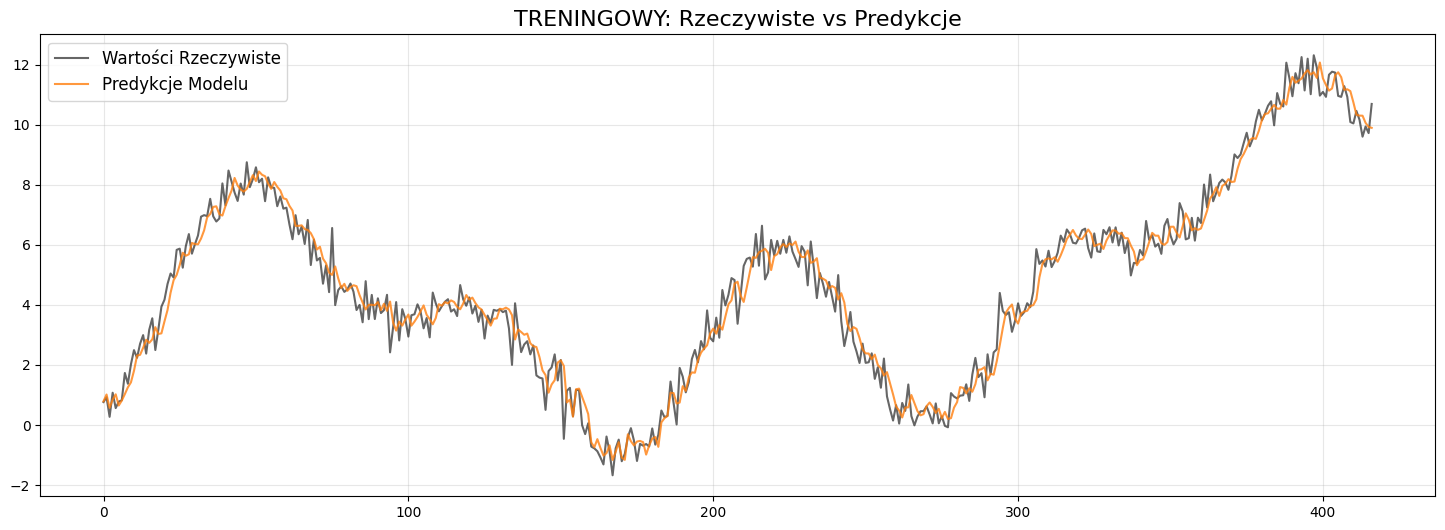

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


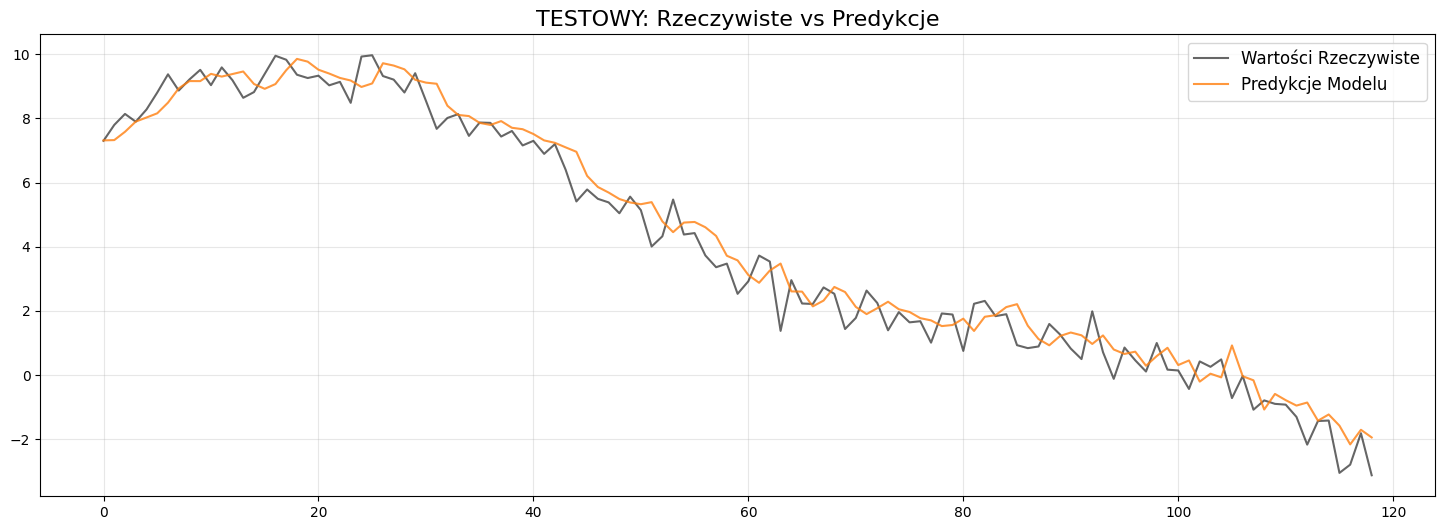

<Sequential name=sequential_31, built=True>

In [138]:
modelcnn = Sequential()
modelcnn.add(InputLayer((seq_len, 1)))
modelcnn.add(Conv1D(64, kernel_size=2, activation='relu', padding="same"))
modelcnn.add(Conv1D(64, kernel_size=2, activation='relu'))
modelcnn.add(Flatten())
modelcnn.add(Dense(8, 'relu'))
modelcnn.add(Dense(1, 'linear'))
modelcnn.summary()

nowy_model(model=modelcnn, epoki1=50, lr1 = 0.001, epoki2=100, lr2 = 0.0001)

## Prosta splotowa sieć radzi sobie równie dobrze co RNN